# TP9 : Analyse de données - Évaluation

## Introduction

La supraconductivité est un phénomène physique où certains matériaux perdent toute résistance électrique en dessous d'une température critique. Ce phénomène a de nombreuses applications (IRM médicales, accélérateurs de particules, trains à lévitation magnétique), mais la plupart des supraconducteurs ne fonctionnent qu'à des températures extrêmement basses, ce qui limite leur utilisation pratique.

L'enjeu scientifique est donc de découvrir des matériaux supraconducteurs à température critique élevée. Pour cela, il faut comprendre comment les propriétés physico-chimiques d'un matériau influencent sa température critique.

### Les données

Le dataset contient 10,000 supraconducteurs décrits par :
- **81 features** : propriétés physico-chimiques incluant la composition atomique (nombre d'atomes de chaque élément), les propriétés atomiques moyennes (masse, rayon, électronégativité, valence, etc.), et des descripteurs structurels
- **1 target** : la température critique de supraconductivité (en Kelvin), variant de 0K à 185K

**Objectif du TP** : Explorer ces données pour comprendre visuellement et quantitativement comment les features expliquent la température critique.

---

**Bibliothèques autorisées** : Vous devez utiliser uniquement les bibliothèques listées ci-dessous. Aucune autre bibliothèque n'est autorisée pour ce TP.

In [ ]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, NMF
from sklearn.manifold import Isomap
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

---

## Exercice 1 : Exploration des données

Chargez les données et réalisez une analyse descriptive et exploratoire. Identifiez au moins deux caractéristiques dans ces données qui pourraient influencervotre analyse par la suite.

**Barème** : /3

(5000, 83)
count    5000.000000
mean       34.195541
std        34.174507
min         0.000325
25%         5.080000
50%        19.900000
75%        63.500000
max       136.000000
Name: critical_temperature, dtype: float64


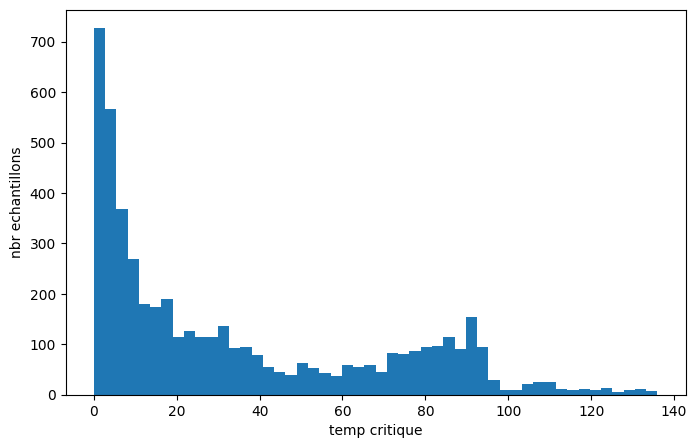

ya des colonne avec des valeurs tres grande comme y en a avec des valeurs minimes donc je pense celle plus grande vont avoir plus d'importance
il y a plein de colonnes qui disent la même chose en double, je pense ca fait bcp trop d'info a la fois (81) ce qui est enorme et on doit reduire apres la taille des features


In [27]:
df= pd.read_csv("superconductivity_data.csv")
X=df.drop(columns=['temp cat','critical_temperature'])
Y=df['critical_temperature']
# print(X)
print(df.shape)
# print(df.info())
print(Y.describe())

plt.figure(figsize=(8,5))
plt.hist(Y,bins=50)
plt.xlabel("temp critique")
plt.ylabel("nbr echantillons")
plt.show()
print("ya des colonne avec des valeurs tres grande comme y en a avec des valeurs minimes donc je pense celle plus grande vont avoir plus d'importance")
print("il y a plein de colonnes qui disent la même chose en double, je pense ca fait bcp trop d'info a la fois (81) ce qui est enorme et on doit reduire apres la taille des features")

---

## Exercice 2 : Visualisation

Créez une visualisation 2D (nuage de points) qui représente au mieux les différences de température critique entre les supraconducteurs. Testez plusieurs approches et identifiez la meilleure.

**Barème** : /6

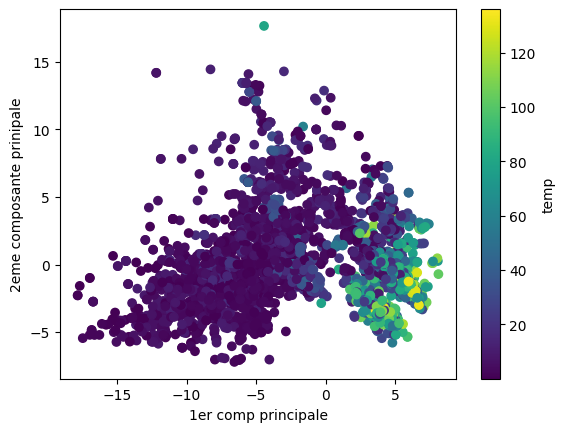

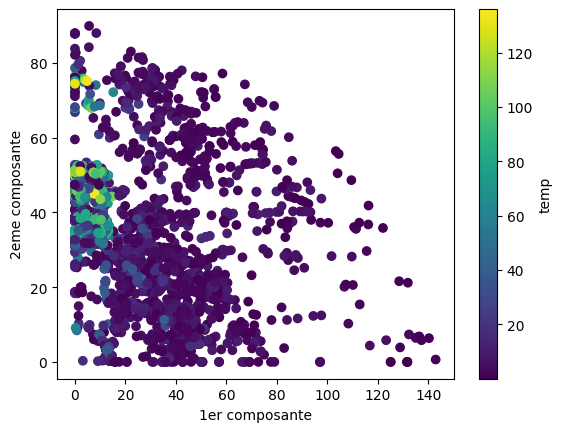

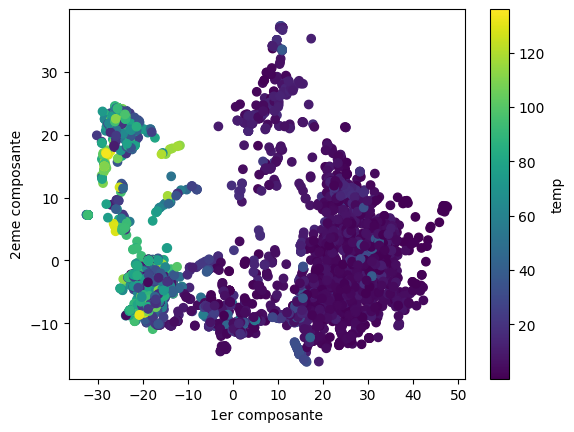

Pca : ca fait un gros nuage un peu etalé.on voit un peu les points jaunes d'un coté mais ca reste assez melangé

 nmf : ca fait une forme un peu bizzare c pas du tout claire

 isomap : je trouve que c'est la meilleure, les points avec temp haute ont l'air d'être un peu mieux regroupés ensemble dans une zone précise à l'écart du gros bloc violet 


In [ ]:

#pca
# centre autour de 0
scaler= StandardScaler()
X_stand=scaler.fit_transform(X)
pca = PCA(n_components=2)
X_pca= pca.fit_transform(X_stand)

plt.scatter(X_pca[:,0],X_pca[:,1],c=Y,cmap='viridis')
plt.colorbar(label="temp")
plt.xlabel("1er comp principale")
plt.ylabel("2eme composante prinipale")
plt.show()
 
#nmf
nmf=NMF(n_components=2,init='random',random_state=42)
x_nmf= nmf.fit_transform(X)
plt.scatter(x_nmf[:, 0],x_nmf[:, 1],c=Y,cmap='viridis')
plt.colorbar(label="temp")
plt.xlabel("1er composante")
plt.ylabel("2eme composante")
plt.show()

#isomap
isomap = Isomap(n_components=2, n_neighbors=15)
X_iso =isomap.fit_transform(X_stand)
plt.scatter(X_iso[:,0], X_iso[:,1],c=Y,cmap='viridis')
plt.colorbar(label="temp")
plt.xlabel("1er composante")
plt.ylabel("2eme composante")
plt.show()


print("Pca : ca fait un gros nuage un peu etalé.on voit un peu les points jaunes d'un coté mais ca reste assez melangé")
print("\n nmf : ca fait une forme un peu bizzare c pas du tout claire")
print("\n isomap : je trouve que c'est la meilleure, les points avec temp haute ont l'air d'être un peu mieux regroupés ensemble dans une zone précise à l'écart du gros bloc violet ")

---

## Exercice 3 : Modélisation prédictive

Construisez un modèle de régression capable de prédire la température critique à partir des 81 features. Testez plusieurs approches et identifiez le meilleur modèle.

**Barème** : /6

In [53]:
# tout a la meme echele
scaler = StandardScaler()
X_stand = scaler.fit_transform(X)

#fonction je l'ai pris du tp8
def train_test_split(data, labels, train_ratio=0.8, seed=42):
    np.random.seed(seed)
    #  indices
    indices = np.random.permutation(len(data))
    split_point = int(len(data) * train_ratio)
    train_indices = indices[:split_point]
    test_indices = indices[split_point:]
    
    # div data et labels
    data_train = data[train_indices]
    data_test = data[test_indices]
    labels_train = labels[train_indices]
    labels_test = labels[test_indices]
    
    return data_train, data_test, labels_train, labels_test

# fonction pour calculer Root Mean Squared Error
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))


#on decoupe les donnés test 0.2 et train 0.8
X_train,X_test,Y_train,Y_test = train_test_split(X_stand,Y, train_ratio=0.8,seed=42)

#je commece par la regression lineaire (1er approche)
regression = LinearRegression()
regression.fit(X_train,Y_train)
y_pred_lr = regression.predict(X_test)
score1= regression.score(X_train,Y_train)
score2= regression.score(X_test,Y_test)
rmse1= rmse(Y_test,y_pred_lr)
print(f"le score de la regression lineaire(train) est{score1}")
print(f"le score de la regression lineaire(test) est{score2}")
print(f"le nmse de la regression lineaire est{rmse1}")

#2eme approche regression lineaire avec pca
pca = PCA(n_components=0.95)#essayer d'eliminer le bruit
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
regression_pca=LinearRegression()
regression_pca.fit(X_train_pca, Y_train)
y_pred_pca = regression_pca.predict(X_test_pca)
score3= regression_pca.score(X_train_pca,Y_train)
score4= regression_pca.score(X_test_pca,Y_test)
rmse2= rmse(Y_test,y_pred_pca)
print("\n")
print(f"le score de la regression lineaire(train) avec pca  est{score3}")
print(f"le score de la regression lineaire(test) avec pca est{score4}")
print(f"le nmse de la regression lineaire avec pca est{rmse2}")

#3eme aproche Ridge avec alpha=1

ridge_1 = Ridge(alpha=1.0)
ridge_1.fit(X_train, Y_train)
y_pred_r1 = ridge_1.predict(X_test)#
score5= ridge_1.score(X_train,Y_train)
score6= ridge_1.score(X_test,Y_test)
rmse3= rmse(Y_test,y_pred_r1)
print("\n")
print(f"le score de Régression Ridge (train) avec alpha=1  est{score5}")
print(f"le score de Régression Ridge(test) avec alpha=1 est{score6}")
print(f"le nmse de la Régression Ridge avec alpha=1 est{rmse3}")

#4eme approche Ridge avec alpha=100
ridge_2 = Ridge(alpha=100.0)
ridge_2.fit(X_train, Y_train)
y_pred_r2 = ridge_2.predict(X_test)#
score7= ridge_2.score(X_train,Y_train)
score8= ridge_2.score(X_test,Y_test)
rmse4= rmse(Y_test,y_pred_r2)
print("\n")
print(f"le score de Régression Ridge (train) avec alpha=100  est{score7}")
print(f"le score de Régression Ridge(test) avec alpha=100 est{score8}")
print(f"le nmse de la Régression Ridge avec alpha=100 est{rmse4}")



le score de la regression lineaire(train) est0.7449673164681461
le score de la regression lineaire(test) est0.7214120988143407
le nmse de la regression lineaire est18.095074718565098


le score de la regression lineaire(train) avec pca  est0.6151656576967969
le score de la regression lineaire(test) avec pca est0.5838124957901769
le nmse de la regression lineaire avec pca est22.116875504731215


le score de Régression Ridge (train) avec alpha=1  est0.7427173751340375
le score de Régression Ridge(test) avec alpha=1 est0.7181824962044914
le nmse de la Régression Ridge avec alpha=1 est18.199658415547756


le score de Régression Ridge (train) avec alpha=100  est0.7179820347157122
le score de Régression Ridge(test) avec alpha=100 est0.6852910208447687
le nmse de la Régression Ridge avec alpha=100 est19.232415018165433


Face à  81 colonnes ou features, j'ai tester 4 approches 

Approche 1 : Régression linéaire classique. C'est mon modèle de basee. meme avc bcp trop de variable.

Approche 2 : Régression lineaire avec PCA. J'ai appliqué une PCA en gardant 95% de la var pour essayer éliminer le bruit je sais pas si c'est bien. j'ai essayer de voir si le modèle est plus performant avec moins d'informations redondantes

Approches 3 et 4 : Régression rigide (avec alpha=1 et alpha=100). C'est une régression pénalisée    


En observant les résultats des différents modèles, on remarque à ma grande surprise, que la Régression Linéaire classique est la meilleure approche (elle a le meilleur score R^2 sur le test, autour de 0.72, et la plus petite erreur)
Contrairement a ce que je pensais, elle ne s'en sort pas moyennement, elle gère très bien les 81 variables
La PCA n'a pas du tout aidé . la PCA a surement supprimé des informations très importantes pour deviner la température



---

## Critères d'évaluation généraux

Votre travail sera évalué sur :

**Rigueur méthodologique** :
- Justification de tous vos choix (méthodes, paramètres, prétraitements)
- Méthodologie d'évaluation appropriée (séparation train/test, validation, métriques)
- Documentation claire de votre démarche

**Exploration et créativité** :
- Variété des approches testées (vous devez tester plusieurs méthodes/paramètres/prétraitements)
- Capacité à proposer et justifier vos propres critères d'évaluation
- Esprit critique sur les résultats obtenus

**Communication** :
- Code clair, commenté et bien organisé
- Tableaux comparatifs de vos différentes approches
- Synthèses concises expliquant vos conclusions

**Important** : Une approche rigoureuse et bien documentée vaut mieux qu'une approche complexe mal justifiée. Expliquez vos choix, comparez vos résultats, et soyez critiques.

**Attention** : L'utilisation de chatbots type ChatGPT est complètement interdite et sera fortement sanctionnée. J'ai été assez clément jusqu'ici mais je vous assure que cela se voit facilement lorsque vous copiez-collez du code ou du texte dans vos TP.

**Barème** : /5